## Exploratory Data Analysis - Baltimore Crime Data


#### Data Source 1 – 

    Data Source - https://data.lacity.org/Public-Safety/Crime-Data-from-2010-to-2019/63jg-8b9z
    Data Name – Crime Data from 2010 to 2019
    Data was found on Kaggle, and list provided by Professor. It is free to download and legal to access. Documented EDA of Data is not available.

    Data Size – Rows (2060948), Columns (28), Size (497 MB)
    
#### Data Source 2 –

    Data Source - https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8
    Data Name – Crime Data from 2020 to Present
    Data was found on list provided by Professor. It is free to download and legal to access. Documented EDA of Data is not available.

    Data Size – Rows (427583), Columns (28), Size (104 MB)

#### Columns Information
    1. DR_NO - Division of Records Number: Official file number made up of a 2 digit year, area ID, and 5 digits
    2. Date Rptd - MM/DD/YYYY
    3. DATE OCC - MM/DD/YYYY
    4. TIME OCC - In 24 hour military time.
    5. AREA - The LAPD has 21 Community Police Stations referred to as Geographic Areas within the department. These Geographic Areas are sequentially numbered from 1-21.
    6. AREA NAME - The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles.
    7. Rpt Dist No	- A four-digit code that represents a sub-area within a Geographic Area. All crime records reference the "RD" that it occurred in for statistical comparisons. Find LAPD Reporting Districts on the LA City GeoHub at http://geohub.lacity.org/datasets/c4f83909b81d4786aa8ba8a74a4b4db1_4
    8. Part 1-2 - Number (Not important)
    9. Crm Cd - Indicates the crime committed. (Same as Crime Code 1)
    10. Crm Cd Desc	- Defines the Crime Code provided.
    11. Mocodes - Modus Operandi: Activities associated with the suspect in commission of the crime.See attached PDF for list of MO Codes in numerical order. https://data.lacity.org/api/views/y8tr-7khq/files/3a967fbd-f210-4857-bc52-60230efe256c?download=true&filename=MO%20CODES%20(numerical%20order).pdf
    12. Vict Age - Two character numeric
    13. Vict Sex - F - Female M - Male X - Unknown
    14. Vict Descent - Descent Code: A - Other Asian B - Black C - Chinese D - Cambodian F - Filipino G - Guamanian H - Hispanic/Latin/Mexican I - American Indian/Alaskan Native J - Japanese K - Korean L - Laotian O - Other P - Pacific Islander S - Samoan U - Hawaiian V - Vietnamese W - White X - Unknown Z - Asian Indian
    15. Premis Cd - The type of structure, vehicle, or location where the crime took place.
    16. Premis Desc - Defines the Premise Code provided.
    17. Weapon Used Cd - The type of weapon used in the crime.
    18. Weapon Desc	- Defines the Weapon Used Code provided.
    19. Status - Status of the case. (IC is the default)
    20. Status Desc	- Defines the Status Code provided.
    21. Crm Cd 1 - Indicates the crime committed. Crime Code 1 is the primary and most serious one. Crime Code 2, 3, and 4 are respectively less serious offenses. Lower crime class numbers are more serious.
    22. Crm Cd 2 - May contain a code for an additional crime, less serious than Crime Code 1.
    23. Crm Cd 3 - May contain a code for an additional crime, less serious than Crime Code 1.
    24. Crm Cd 4 - May contain a code for an additional crime, less serious than Crime Code 1.
    25. LOCATION - Street address of crime incident rounded to the nearest hundred block to maintain anonymity.
    26. Cross Street - Cross Street of rounded Address
    27. LAT - Latitude
    28. LON - Longtitude

#### Breakdown of the project – 

    1. Loading dataset, Combining two datasets, and Cleaning.
    2. Finding relationship between features of dataset
    3. Creating visulization based on found relationships

In [1]:
# Importing required Libraries

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Display all the columns of the dataframe

#pd.pandas.set_option('display.max_columns', None)

In [2]:
# Importing dataset 1

start_time = time.time()
dataset1 = pd.read_csv("Crime_Data_from_2010_to_2019.csv")
print(time.time() - start_time,'seconds')
print(dataset1.shape)

9.97288703918457 seconds
(2060948, 28)


In [3]:
dataset1.head().T

,0,1,2,3,4
DR_NO,1307355,11401303,70309629,90631215,100100501
Date Rptd,02/20/2010 12:00:00 AM,09/13/2010 12:00:00 AM,08/09/2010 12:00:00 AM,01/05/2010 12:00:00 AM,01/03/2010 12:00:00 AM
DATE OCC,02/20/2010 12:00:00 AM,09/12/2010 12:00:00 AM,08/09/2010 12:00:00 AM,01/05/2010 12:00:00 AM,01/02/2010 12:00:00 AM
TIME OCC,1350,45,1515,150,2100
AREA,13,14,13,6,1
AREA NAME,Newton,Pacific,Newton,Hollywood,Central
Rpt Dist No,1385,1485,1324,646,176
Part 1-2,2,2,2,2,1
Crm Cd,900,740,946,900,122
Crm Cd Desc,VIOLATION OF COURT ORDER,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",OTHER MISCELLANEOUS CRIME,VIOLATION OF COURT ORDER,"RAPE, ATTEMPTED"


In [4]:
# Importing dataset 2

start_time = time.time()
dataset2 = pd.read_csv("Crime_Data_from_2020_to_Present.csv")
print(time.time() - start_time,'seconds')
print(dataset2.shape)

2.2069318294525146 seconds
(427583, 28)


In [5]:
dataset2.head().T

,0,1,2,3,4
DR_NO,10304468,190101086,191501505,191921269,200100501
Date Rptd,01/08/2020 12:00:00 AM,01/02/2020 12:00:00 AM,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,01/02/2020 12:00:00 AM
DATE OCC,01/08/2020 12:00:00 AM,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM
TIME OCC,2230,330,1730,415,30
AREA,3,1,15,19,1
AREA NAME,Southwest,Central,N Hollywood,Mission,Central
Rpt Dist No,377,163,1543,1998,163
Part 1-2,2,2,2,2,1
Crm Cd,624,624,745,740,121
Crm Cd Desc,BATTERY - SIMPLE ASSAULT,BATTERY - SIMPLE ASSAULT,VANDALISM - MISDEAMEANOR ($399 OR UNDER),"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...","RAPE, FORCIBLE"


In [6]:
# Combining both Datasets and creating final dataframe

dataset = pd.concat([dataset1,dataset2])

In [7]:
dataset.shape
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2488531 entries, 0 to 427582
Data columns (total 29 columns):
 #   Column          Dtype  
---  ------          -----  
 0   DR_NO           int64  
 1   Date Rptd       object 
 2   DATE OCC        object 
 3   TIME OCC        int64  
 4   AREA            float64
 5   AREA NAME       object 
 6   Rpt Dist No     int64  
 7   Part 1-2        int64  
 8   Crm Cd          int64  
 9   Crm Cd Desc     object 
 10  Mocodes         object 
 11  Vict Age        int64  
 12  Vict Sex        object 
 13  Vict Descent    object 
 14  Premis Cd       float64
 15  Premis Desc     object 
 16  Weapon Used Cd  float64
 17  Weapon Desc     object 
 18  Status          object 
 19  Status Desc     object 
 20  Crm Cd 1        float64
 21  Crm Cd 2        float64
 22  Crm Cd 3        float64
 23  Crm Cd 4        float64
 24  LOCATION        object 
 25  Cross Street    object 
 26  LAT             float64
 27  LON             float64
 28  AREA         

In [8]:
dataset.head().T

,0,1,2,3,4
DR_NO,1307355,11401303,70309629,90631215,100100501
Date Rptd,02/20/2010 12:00:00 AM,09/13/2010 12:00:00 AM,08/09/2010 12:00:00 AM,01/05/2010 12:00:00 AM,01/03/2010 12:00:00 AM
DATE OCC,02/20/2010 12:00:00 AM,09/12/2010 12:00:00 AM,08/09/2010 12:00:00 AM,01/05/2010 12:00:00 AM,01/02/2010 12:00:00 AM
TIME OCC,1350,45,1515,150,2100
AREA,13.0,14.0,13.0,6.0,1.0
AREA NAME,Newton,Pacific,Newton,Hollywood,Central
Rpt Dist No,1385,1485,1324,646,176
Part 1-2,2,2,2,2,1
Crm Cd,900,740,946,900,122
Crm Cd Desc,VIOLATION OF COURT ORDER,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",OTHER MISCELLANEOUS CRIME,VIOLATION OF COURT ORDER,"RAPE, ATTEMPTED"


In [9]:
## Here we will check the percentage of nan values present in each feature

## Step 1 - Make the list of features which has missing values

features_with_na = [features for features in dataset.columns if dataset[features].isnull().sum()>1]

## Step 2 - Print the feature name and percentage of missing values

for feature in features_with_na:
    print(feature, np.round(dataset[feature].isnull().mean(), 4), '% missing values')


AREA  0.1718 % missing values
Mocodes 0.1163 % missing values
Vict Sex 0.1039 % missing values
Vict Descent 0.1039 % missing values
Premis Cd 0.0 % missing values
Premis Desc 0.0002 % missing values
Weapon Used Cd 0.6557 % missing values
Weapon Desc 0.6557 % missing values
Status 0.0 % missing values
Crm Cd 1 0.0 % missing values
Crm Cd 2 0.9294 % missing values
Crm Cd 3 0.998 % missing values
Crm Cd 4 0.9999 % missing values
Cross Street 0.8287 % missing values
AREA 0.8282 % missing values


### Temporal Variables (Eg: Datetime Variables)
Finding datetime variables and doing analysis on them

In [10]:
temporal_features = [feature for feature in dataset.columns if 'date' in feature.lower()]
temporal_features

['Date Rptd', 'DATE OCC']

In [11]:
dataset['Date Rptd']=pd.to_datetime(dataset['Date Rptd'])

2021    321701
2020    314991
2018    229565
2017    225954
2019    219956
Name: Year, dtype: int64


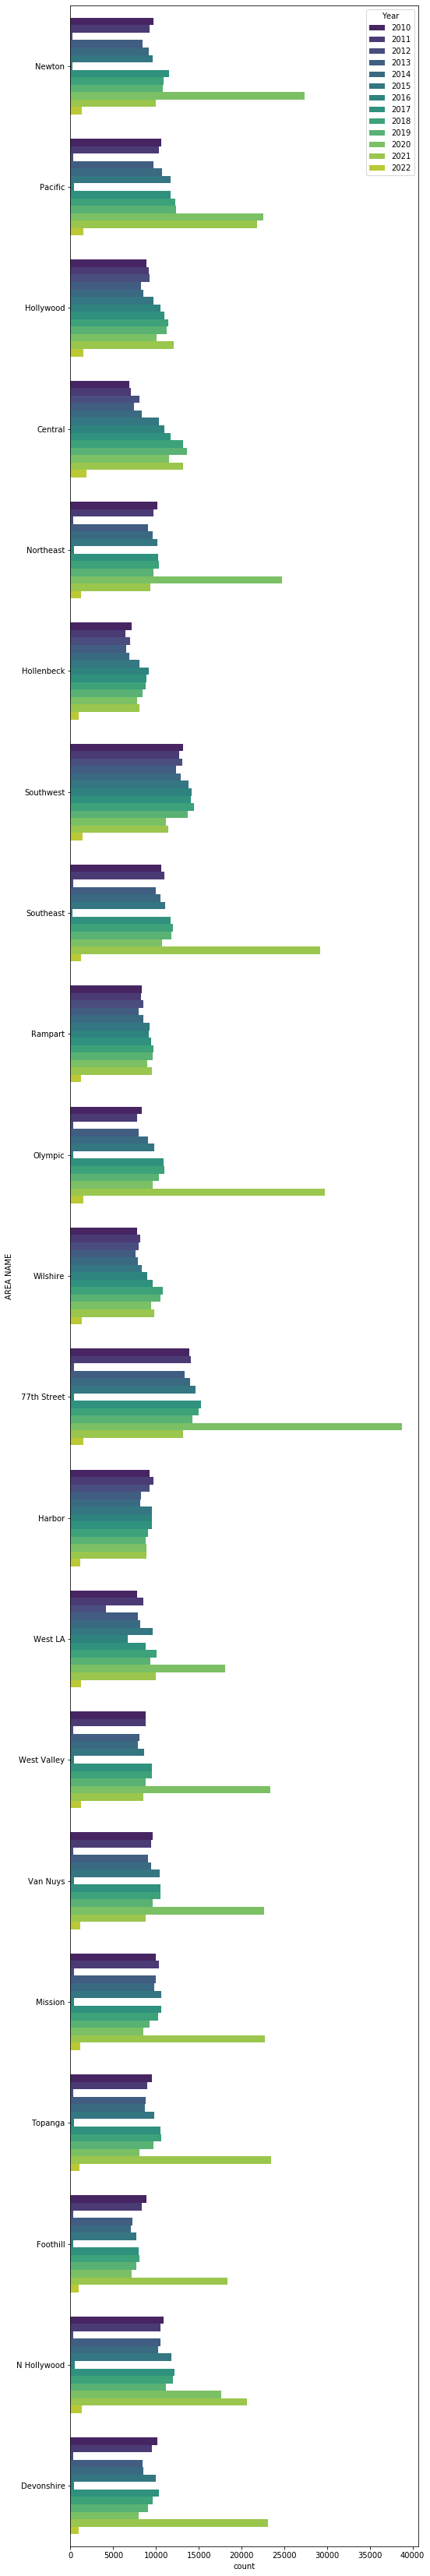

In [12]:
# Creating the Year column
dataset['Year'] = dataset['Date Rptd'].apply(lambda time : time.year)
print(dataset['Year'].value_counts().head())
plt.figure(figsize=(8,60))
sns.countplot(y='AREA NAME',data=dataset,hue='Year',palette='viridis')

In [13]:
time=dataset['Date Rptd'].iloc[0]
dataset['Hour']=dataset['Date Rptd'].apply(lambda time:time.hour)
dataset['Month']=dataset['Date Rptd'].apply(lambda time:time.month)
dataset['Day of Week']=dataset['Date Rptd'].apply(lambda time:time.dayofweek)

In [14]:
# Create dictionary for the Months
month_map = {0:'Jan',1:'Feb',2:'Mar',3:'April',4:'May',5:'Jun',6:'Jul', 7:'Aug', 8:'Sep', 9: 'Oct',10: 'Nov', 11: 'Dec'}
month_map

{0: 'Jan',
 1: 'Feb',
 2: 'Mar',
 3: 'April',
 4: 'May',
 5: 'Jun',
 6: 'Jul',
 7: 'Aug',
 8: 'Sep',
 9: 'Oct',
 10: 'Nov',
 11: 'Dec'}

In [15]:
# Mapping Month names
dataset['Month'] = dataset['Month'].map(month_map)
dataset['Month'].value_counts()

Feb      220545
Aug      217414
Sep      216720
Nov      213134
Jun      211733
Jul      209374
Oct      207438
April    205164
May      201321
Dec      199486
Mar      194877
Name: Month, dtype: int64

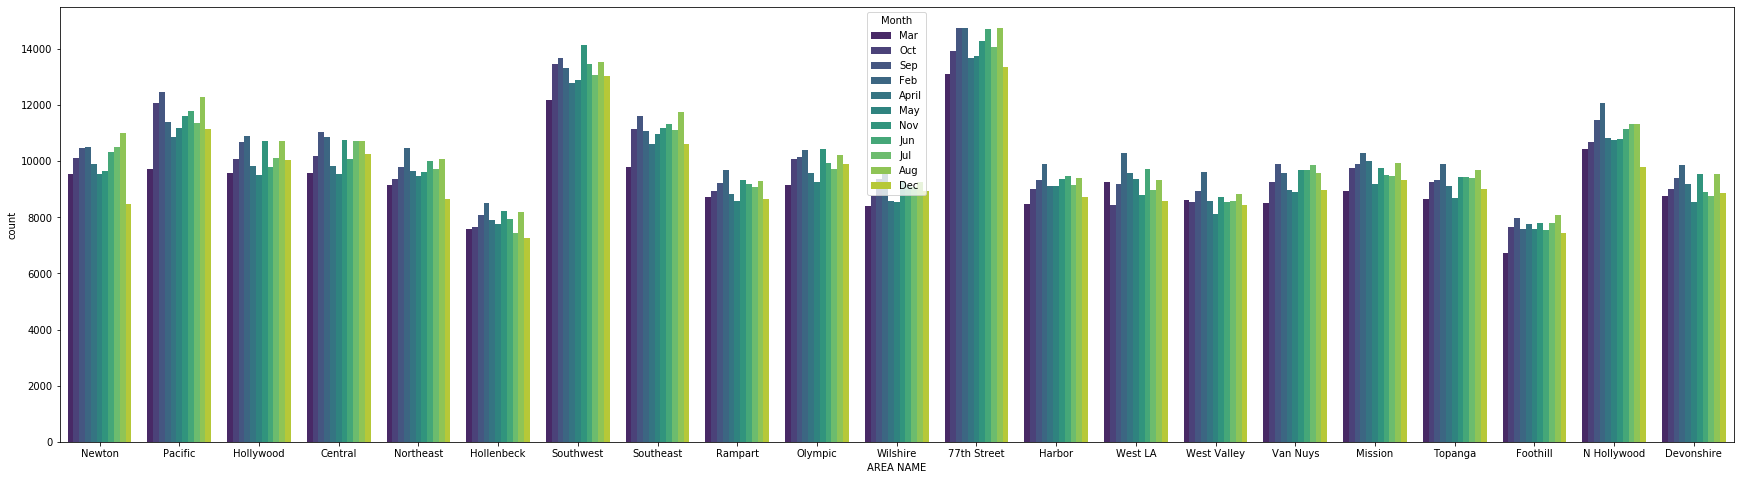

In [16]:
plt.figure(figsize=(30,8))
sns.countplot(x='AREA NAME',data=dataset,hue='Month',palette='viridis')

In [17]:
dmap={0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
dataset['Day of Week']=dataset['Day of Week'].map(dmap)

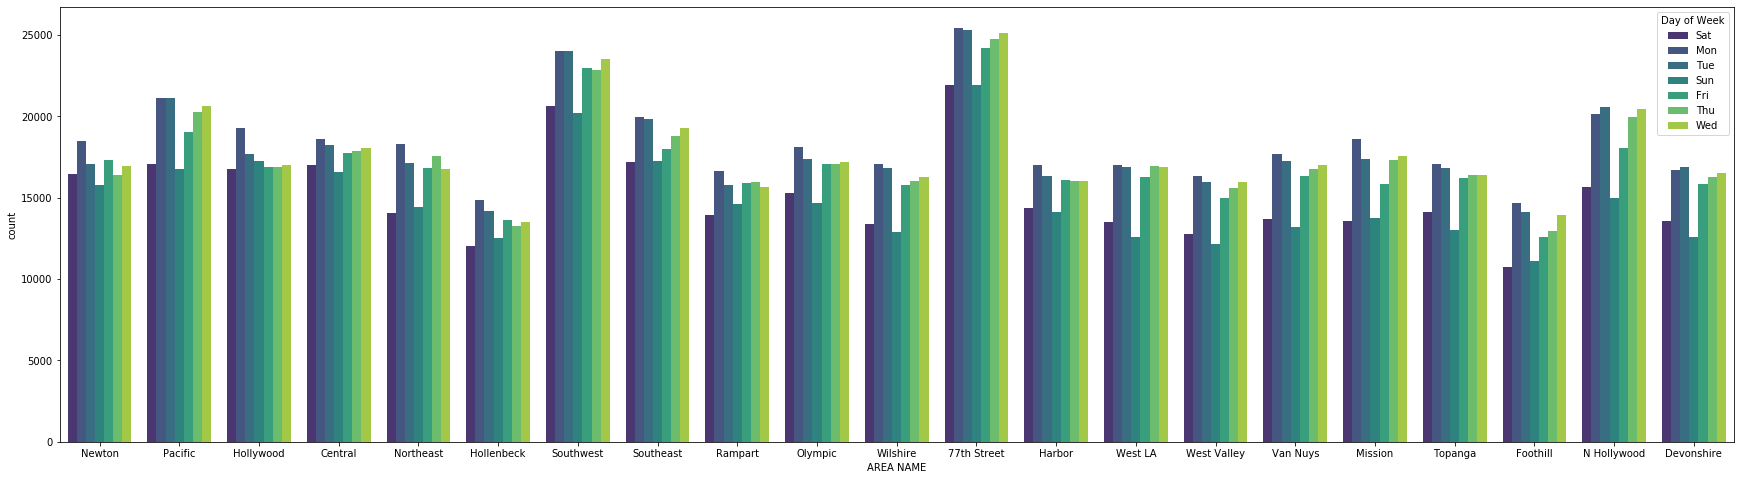

In [18]:
plt.figure(figsize=(30,8))
sns.countplot(x='AREA NAME',data=dataset,hue='Day of Week',palette='viridis')

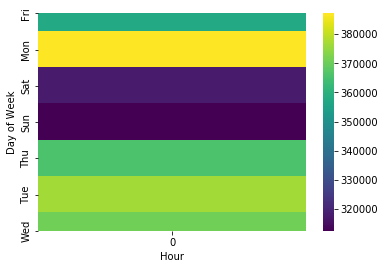

In [19]:
dayHour = dataset.groupby(by=['Day of Week','Hour']).count()['Status Desc'].unstack()
dayHour.head()
sns.heatmap(dayHour,cmap='viridis')

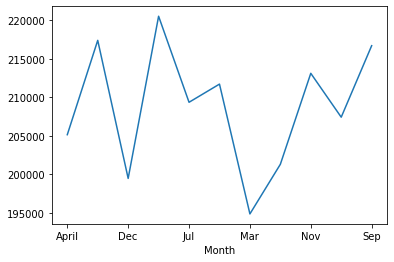

In [20]:
Month_group = dataset.groupby(['Month']).count()
Month_group['AREA NAME'].plot()

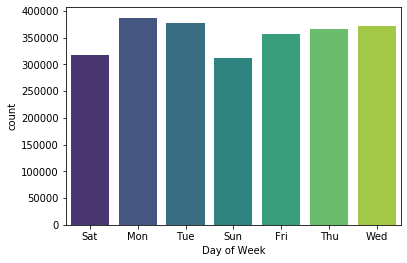

In [21]:
# Analyzing the week column

dataset['Day of Week'].value_counts()
sns.countplot(x='Day of Week',data=dataset,palette='viridis')

### Categorical Variables

In [22]:
data = dataset.copy()
categorical_features = [feature for feature in dataset.columns if data[feature].dtypes=='O']
categorical_features

['DATE OCC',
 'AREA NAME',
 'Crm Cd Desc',
 'Mocodes',
 'Vict Sex',
 'Vict Descent',
 'Premis Desc',
 'Weapon Desc',
 'Status',
 'Status Desc',
 'LOCATION',
 'Cross Street',
 'Month',
 'Day of Week']

In [23]:
dataset[categorical_features].head()

,DATE OCC,AREA NAME,Crm Cd Desc,Mocodes,Vict Sex,Vict Descent,Premis Desc,Weapon Desc,Status,Status Desc,LOCATION,Cross Street,Month,Day of Week
0,02/20/2010 12:00:00 AM,Newton,VIOLATION OF COURT ORDER,0913 1814 2000,M,H,SINGLE FAMILY DWELLING,NaN,AA,Adult Arrest,300 E GAGE AV,NaN,Mar,Sat
1,09/12/2010 12:00:00 AM,Pacific,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,M,W,STREET,NaN,IC,Invest Cont,SEPULVEDA BL,MANCHESTER AV,Oct,Mon
2,08/09/2010 12:00:00 AM,Newton,OTHER MISCELLANEOUS CRIME,0344,M,H,ALLEY,NaN,IC,Invest Cont,1300 E 21ST ST,NaN,Sep,Mon
3,01/05/2010 12:00:00 AM,Hollywood,VIOLATION OF COURT ORDER,1100 0400 1402,F,W,STREET,HAND GUN,IC,Invest Cont,CAHUENGA BL,HOLLYWOOD BL,Feb,Tue
4,01/02/2010 12:00:00 AM,Central,"RAPE, ATTEMPTED",0400,F,H,ALLEY,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,8TH ST,SAN PEDRO ST,Feb,Sun


In [24]:
for feature in categorical_features:
    print("The feature is {} and number of categories are {}".format(feature, len(dataset[feature].unique())))

The feature is DATE OCC and number of categories are 4428
The feature is AREA NAME and number of categories are 21
The feature is Crm Cd Desc and number of categories are 146
The feature is Mocodes and number of categories are 562367
The feature is Vict Sex and number of categories are 7
The feature is Vict Descent and number of categories are 21
The feature is Premis Desc and number of categories are 320
The feature is Weapon Desc and number of categories are 80
The feature is Status and number of categories are 9
The feature is Status Desc and number of categories are 6
The feature is LOCATION and number of categories are 78950
The feature is Cross Street and number of categories are 13900
The feature is Month and number of categories are 12
The feature is Day of Week and number of categories are 7


77th Street    168676
Southwest      158268
Pacific        136036
Southeast      130354
N Hollywood    129830
Central        124065
Hollywood      121766
Newton         118477
Olympic        116818
Northeast      115035
Mission        114050
Van Nuys       111944
West LA        110111
Topanga        110031
Harbor         109995
Rampart        108505
Devonshire     108368
Wilshire       108215
West Valley    103778
Hollenbeck      94047
Foothill        90162
Name: AREA NAME, dtype: int64


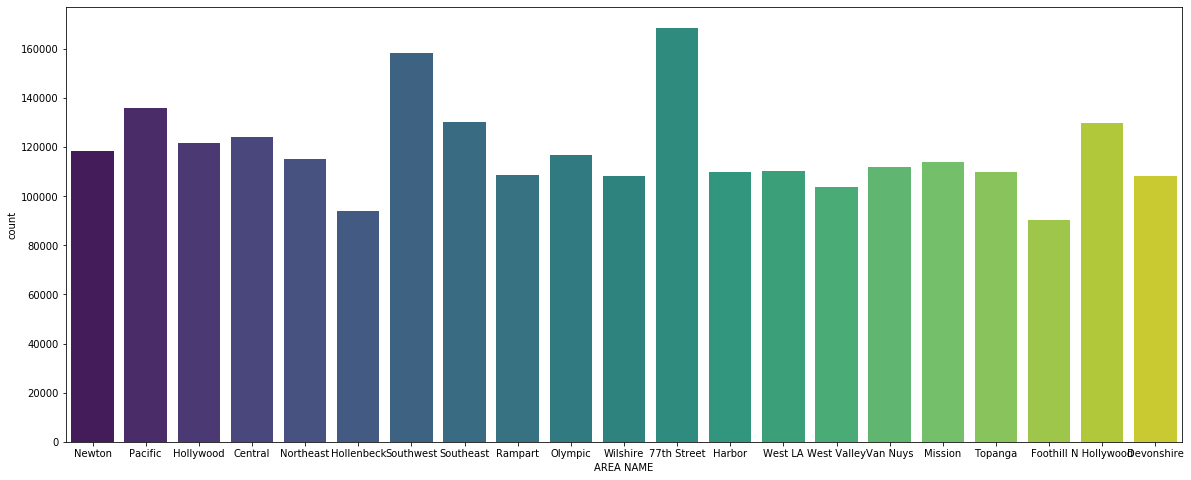

In [25]:
## Area-wise Crime Count

print(dataset['AREA NAME'].value_counts())
plt.figure(figsize=(20,8))
sns.countplot(x='AREA NAME',data=dataset,palette='viridis')

## Sex-wise Crime Count

    F - Female 
    M - Male 
    X - Unknown

M    1121671
F    1006963
X     101104
H        143
N         17
-          1
Name: Vict Sex, dtype: int64


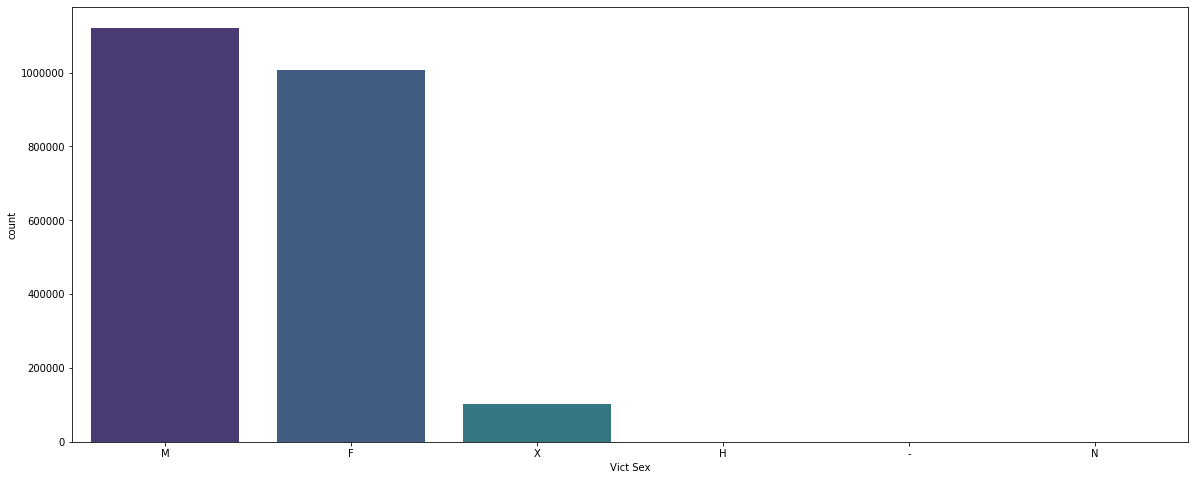

In [26]:
print(dataset['Vict Sex'].value_counts())
plt.figure(figsize=(20,8))
sns.countplot(x='Vict Sex',data=dataset,palette='viridis')

## Victim Descent Crime Count
    Descent Code: 
    A - Other Asian 
    B - Black 
    C - Chinese 
    D - Cambodian 
    F - Filipino 
    G - Guamanian 
    H - Hispanic/Latin/Mexican 
    I - American Indian/Alaskan Native 
    J - Japanese 
    K - Korean 
    L - Laotian 
    O - Other 
    P - Pacific Islander 
    S - Samoan 
    U - Hawaiian 
    V - Vietnamese 
    W - White 
    X - Unknown 
    Z - Asian Indian

H    830127
W    577233
B    385516
O    228175
X    127628
A     58481
K     11020
F      4605
C      2628
I      1324
J      1080
V       692
P       439
Z       345
U       285
G       123
D        54
S        52
L        42
-         2
Name: Vict Descent, dtype: int64


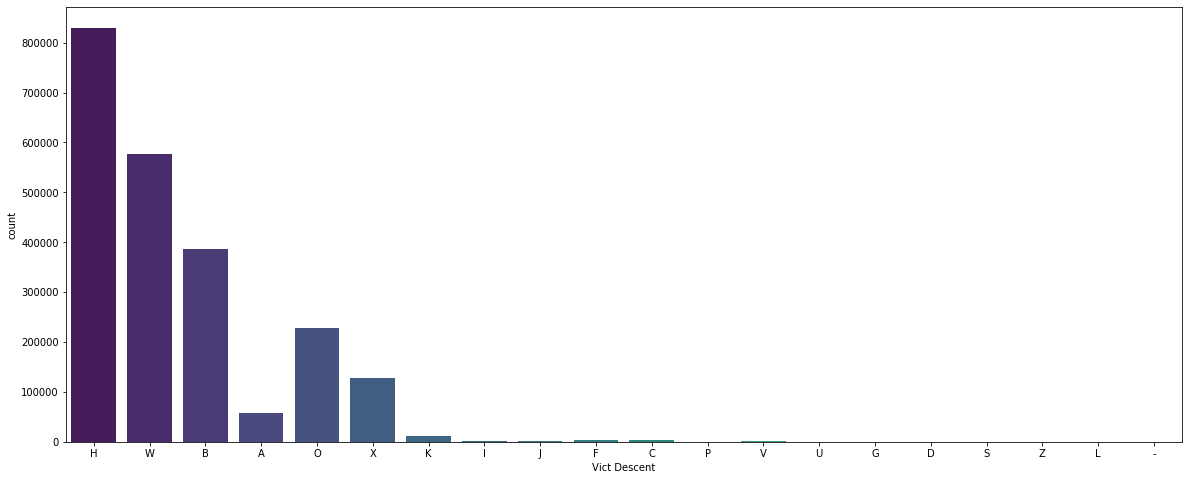

In [27]:
print(dataset['Vict Descent'].value_counts())
plt.figure(figsize=(20,8))
sns.countplot(x='Vict Descent',data=dataset,palette='viridis')

STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    502863
UNKNOWN WEAPON/OTHER WEAPON                        74601
VERBAL THREAT                                      68176
HAND GUN                                           43867
SEMI-AUTOMATIC PISTOL                              16929
                                                   ...  
MAC-10 SEMIAUTOMATIC ASSAULT WEAPON                   13
ANTIQUE FIREARM                                       11
MAC-11 SEMIAUTOMATIC ASSAULT WEAPON                   10
M1-1 SEMIAUTOMATIC ASSAULT RIFLE                       6
M-14 SEMIAUTOMATIC ASSAULT RIFLE                       1
Name: Weapon Desc, Length: 79, dtype: int64


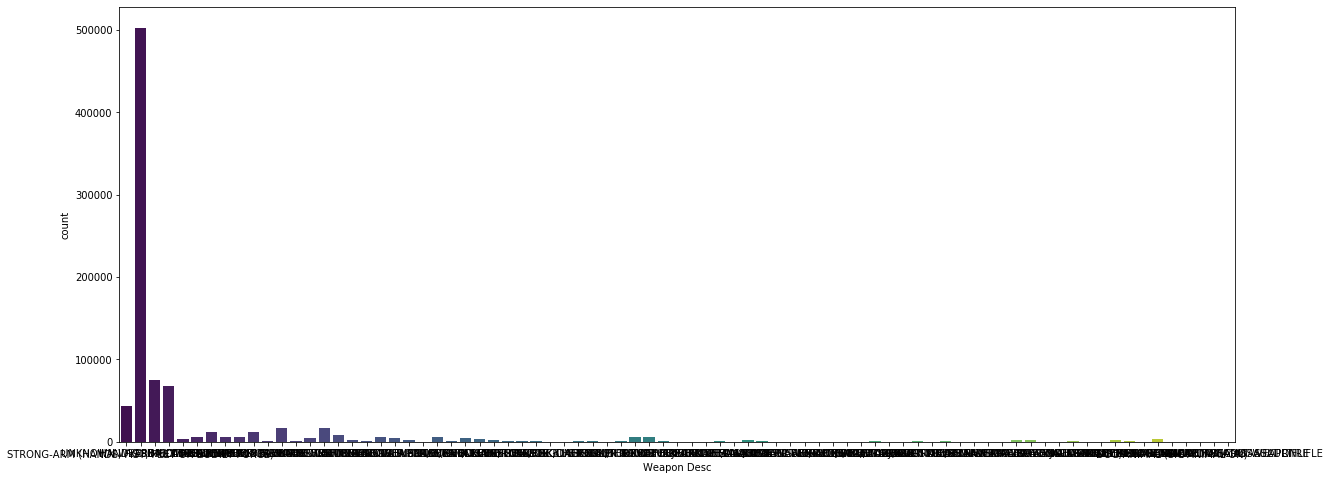

In [28]:
print(dataset['Weapon Desc'].value_counts())
plt.figure(figsize=(20,8))
sns.countplot(x='Weapon Desc',data=dataset,palette='viridis')

Invest Cont     1928738
Adult Other      290685
Adult Arrest     248141
Juv Arrest        15544
Juv Other          5390
UNK                  33
Name: Status Desc, dtype: int64


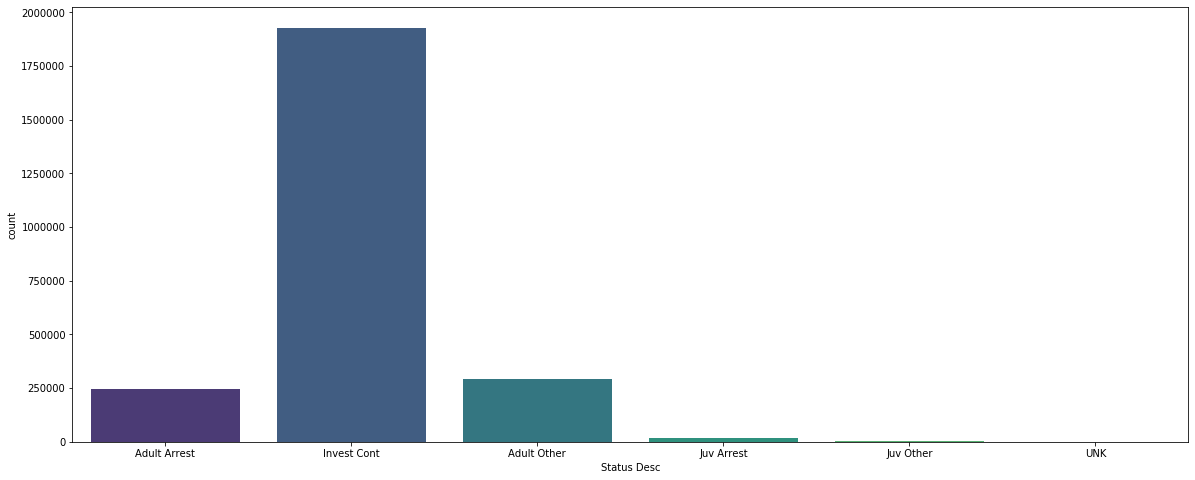

In [29]:
print(dataset['Status Desc'].value_counts())
plt.figure(figsize=(20,8))
sns.countplot(x='Status Desc',data=dataset,palette='viridis')

## Crime Code wise Analysis

    Indicates the crime committed. 
    Crime Code 1 is the primary and most serious one.
    Crime Code 2, 3, and 4 are respectively less serious offenses.
    Lower crime class numbers are more serious.

624.0    219755
510.0    211426
330.0    182449
310.0    167547
440.0    165209
          ...  
453.0         1
999.0         1
486.0         1
111.0         1
905.0         1
Name: Crm Cd 1, Length: 149, dtype: int64


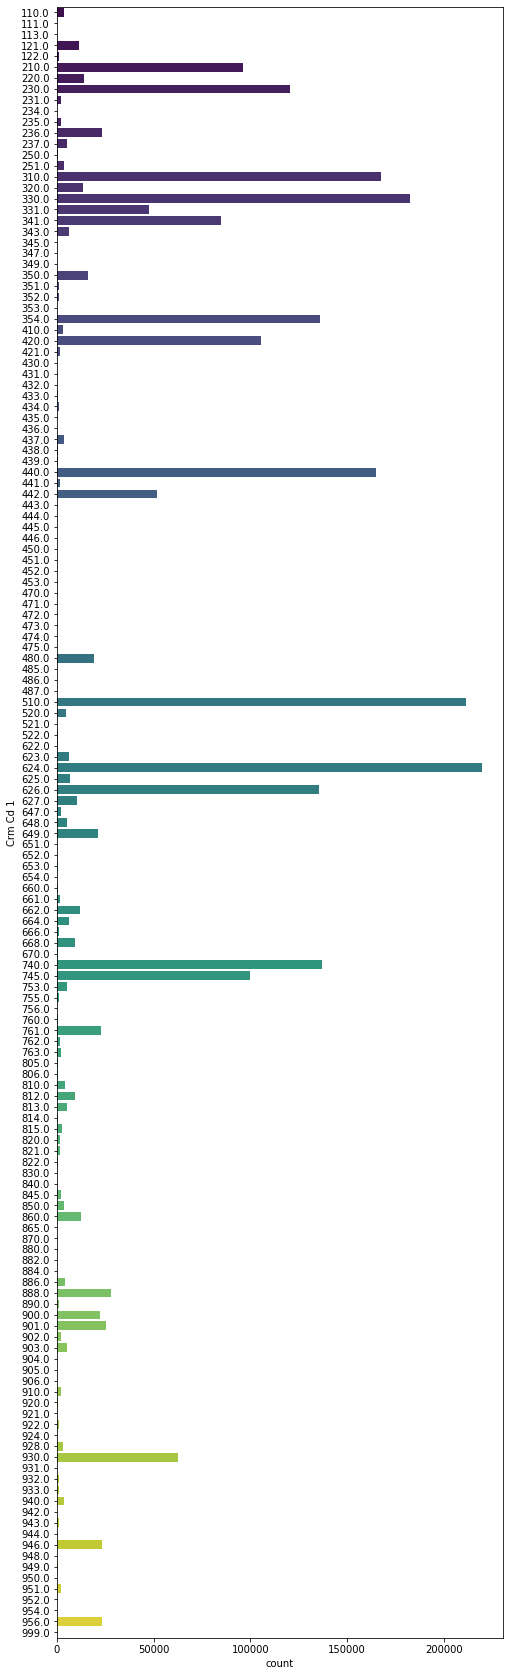

In [30]:
# Analyzing the Crime Code1 column

print(dataset['Crm Cd 1'].value_counts())
plt.figure(figsize=(8,30))
sns.countplot(y='Crm Cd 1',data=dataset,palette='viridis')

## Weapon Description wise Analysis

    Defines weapon used in the crime.

STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    502863
UNKNOWN WEAPON/OTHER WEAPON                        74601
VERBAL THREAT                                      68176
HAND GUN                                           43867
SEMI-AUTOMATIC PISTOL                              16929
                                                   ...  
MAC-10 SEMIAUTOMATIC ASSAULT WEAPON                   13
ANTIQUE FIREARM                                       11
MAC-11 SEMIAUTOMATIC ASSAULT WEAPON                   10
M1-1 SEMIAUTOMATIC ASSAULT RIFLE                       6
M-14 SEMIAUTOMATIC ASSAULT RIFLE                       1
Name: Weapon Desc, Length: 79, dtype: int64


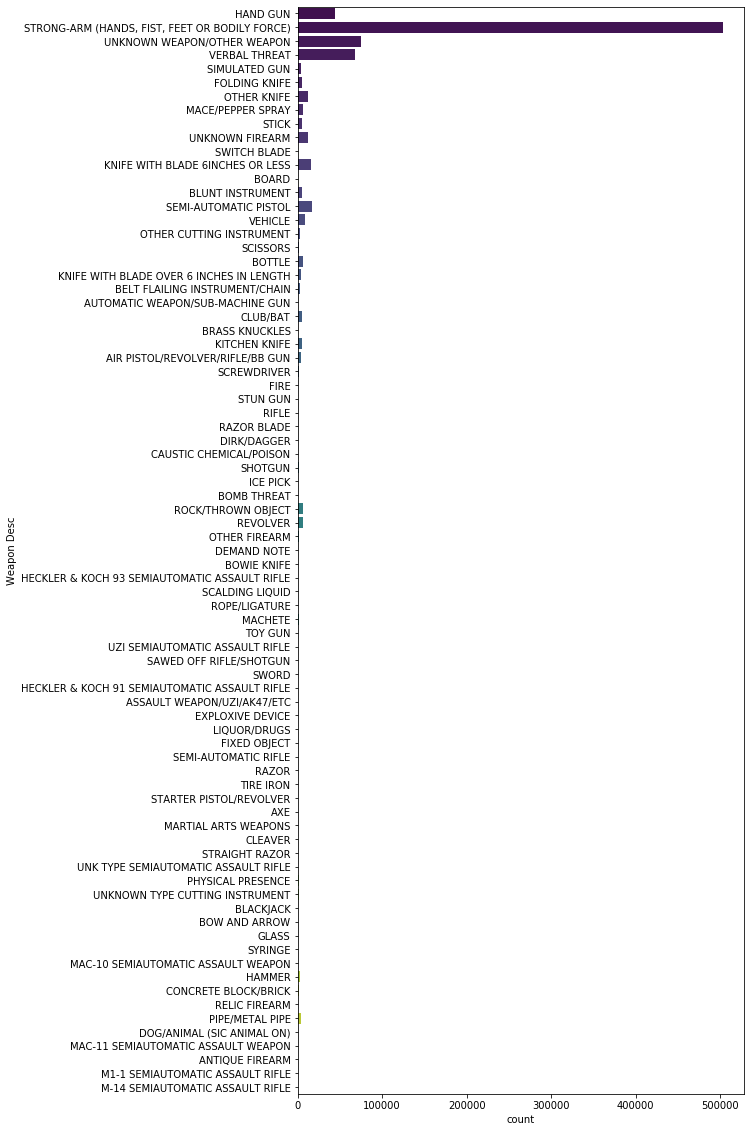

In [31]:
# Analyzing the Weapon column

print(dataset['Weapon Desc'].value_counts())
plt.figure(figsize=(8,20))
sns.countplot(y='Weapon Desc',data=dataset,palette='viridis')